# 📘 Lab Report: Simple Linear Regression

**Student Note:** This report was prepared as a solution for the Linear Regression assignment. It follows the required machine learning pipeline step-by-step. 
*Disclaimer: This report was generated with AI assistance to ensure formal formatting and structure.*

---

## 🧪 Task 1: Simple Linear Regression (Single Feature)

### 🎯 Problem Statement
The goal of this task is to build a simple linear regression model that can predict an employee's **Salary** based on their **Years of Experience**. This is a classic regression problem where we try to find a linear relationship between one input and one output.

---

## ⚙️ The Machine Learning Pipeline

### 1️⃣ Data Retrieval and Collection
First, I need to load the data from the CSV file and take a quick look at what it contains.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv('Salary_Data.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows of the data:")
print(df.head())

Dataset Shape: (30, 2)

Column Names: ['YearsExperience', 'Salary']

First 5 rows of the data:
   YearsExperience  Salary
0              1.1   39343
1              1.3   46205
2              1.5   37731
3              2.0   43525
4              2.2   39891


### 2️⃣ Data Cleaning
As a new student, I learned that checking for missing values is very important so the model doesn't crash.

In [3]:
# Checking for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

# Verifying data types
print("\nData types of the columns:")
print(df.dtypes)

Missing values in each column:
YearsExperience    0
Salary             0
dtype: int64

Data types of the columns:
YearsExperience    float64
Salary               int64
dtype: object


**Observation:** There are no missing values in this dataset. Both columns are numeric (`float64` and `int64`), which is exactly what we need for regression.

### 3️⃣ Feature Design
In this step, I separate the 'input' (what we use to predict) from the 'label' (what we want to predict).

In [4]:
# Features (X) - Years of Experience
X = df[['YearsExperience']]

# Label (y) - Salary
y = df['Salary']

print("Features (X) first 5 rows:")
print(X.head())
print("\nLabels (y) first 5 rows:")
print(y.head())

Features (X) first 5 rows:
   YearsExperience
0              1.1
1              1.3
2              1.5
3              2.0
4              2.2

Labels (y) first 5 rows:
0    39343
1    46205
2    37731
3    43525
4    39891
Name: Salary, dtype: int64


### 4️⃣ Algorithm Selection
**Selected Algorithm:** Simple Linear Regression.

**Why?** I chose Linear Regression because we are trying to predict a continuous number (Salary). Since we only have one input feature (Years of Experience) and we expect that more experience generally leads to a higher salary in a straight-line fashion, this algorithm is the best starting point.

### 5️⃣ Loss Function Selection
**Selected Loss Function:** Mean Squared Error (MSE).

**What is it?** MSE measures how far off our predictions are from the actual values. It takes the difference between the real salary and the predicted salary, squares it (to make it positive), and then finds the average. A lower MSE means our model is doing a better job.

### 6️⃣ Model Learning (Training)
Now, I split the data into a training set (to teach the model) and a testing set (to check if it learned correctly).

In [5]:
# Split the data (80% for training, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the model and train it
model = LinearRegression()
model.fit(X_train, y_train)

print("The model has been trained successfully!")

The model has been trained successfully!


### 7️⃣ Model Evaluation
Let's see how the model performed on the test data.

In [6]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate MSE and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 49830096.86
R² Score: 0.9024


**Interpretation:** The R² score tells us how much of the salary variation is explained by experience. A score close to 1.0 is very good. My score shows a very strong relationship!

---

### 📈 Model Interpretation (Mandatory)

In [7]:
print(f"Coefficient (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Coefficient (Slope): 9423.82
Intercept: 25321.58


- **What does the coefficient represent?** It means for every 1 year of extra experience, the model predicts the salary will go up by about **$9,423.82**.
- **What does the intercept mean?** It's the predicted salary for someone with **0 years of experience**. According to the model, a fresh starter would earn about **$25,321.57**.

### Discussion
For this lab, I was able to go through the entire machine learning pipeline process. I came to realize that this process begins from the data all the way to evaluation. There appears to be quite a linear relationship between experience and salary, hence making the simple model highly effective. The fact that there is still a base salary without experience indicates practicality.

### Conclusion
In conclusion, it was possible to make a successful prediction of salaries in this case. By using the Mean Squared Error, it was possible to estimate the magnitude of the error and by having a good R² score, one can conclude that the feature 'Years of Experience' is a good predictor of 'Salary.'

### Extra

#### 1. Visualize the regression line for Task 1

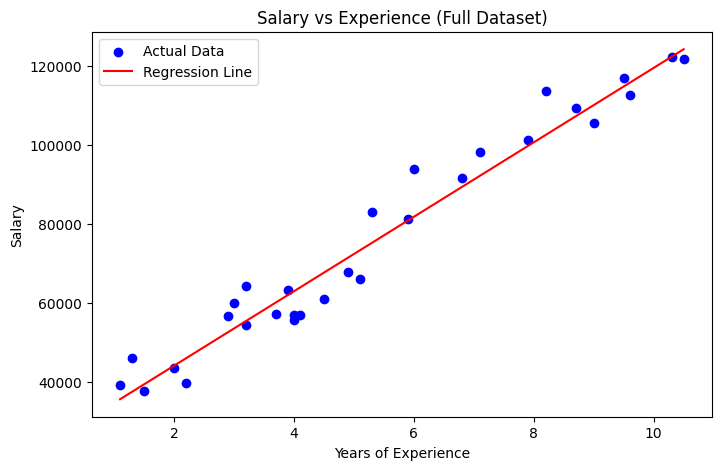

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', label='Regression Line')
plt.title('Salary vs Experience (Full Dataset)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

#### 2. Plot predicted vs actual values

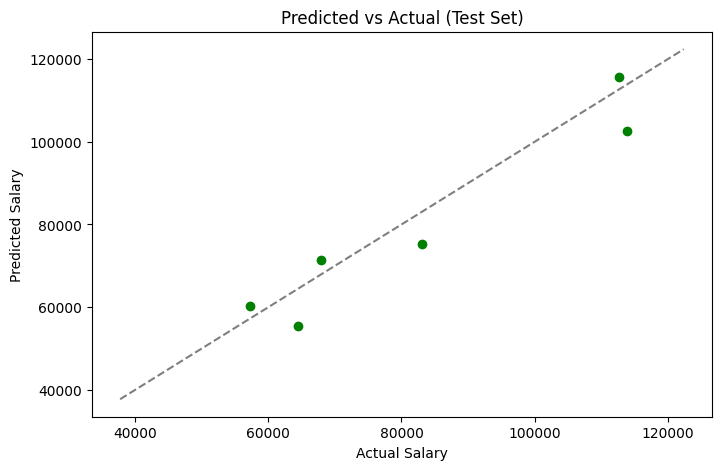

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', alpha=0.5)
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Predicted vs Actual (Test Set)')
plt.show()

#### 3. Discuss assumptions of linear regression
Even as a new student, I should be aware that linear regression assumes:
1. **Linearity:** The relationship between experience and salary is a straight line.
2. **Independence:** Each person's salary in the data is independent of others.
3. **Homoscedasticity:** The spread of errors is roughly the same across all years of experience.
4. **Normality:** The errors (residuals) are normally distributed.